In [1]:
from Bio import SeqIO
import numpy as np

def one_hot_encode_dna(sequence):
    """
    Converts a DNA string to a one-hot encoded NumPy array.
    Encoding Order: A -> [1,0,0,0], C -> [0,1,0,0], G -> [0,0,1,0], T -> [0,0,0,1]
    Unknown bases (e.g., 'N') remain [0,0,0,0].
    """
    seq_array = np.array(list(sequence.upper()))
    one_hot = np.zeros((len(sequence), 4), dtype=np.int8)
    
    one_hot[seq_array == 'A', 0] = 1
    one_hot[seq_array == 'C', 1] = 1
    one_hot[seq_array == 'G', 2] = 1
    one_hot[seq_array == 'T', 3] = 1
    
    return one_hot

def process_all_fasta_sequences(file_path):
    """
    Reads ALL sequences from a FASTA file using Biopython
    and returns a dictionary mapping sequence IDs to their one-hot encoded matrices.
    """
    encoded_sequences = []
    
    # SeqIO.parse reads records one by one, making it highly memory-efficient
    for record in SeqIO.parse(file_path, "fasta"):
        seq_id = record.id
        sequence_str = str(record.seq)
        
        # Encode the sequence and store it
        encoded_sequences.append(one_hot_encode_dna(sequence_str))
        
    return np.stack(encoded_sequences, axis=0)


all_encoded_data = process_all_fasta_sequences("/gpfs/data/zhou-lab/dcai/059_DT/1_meCpG_STAP/data_500/data_500.fa")

In [5]:
import pandas as pd
import numpy as np
import logomaker
import logging
logging.getLogger('matplotlib.font_manager').setLevel(level=logging.ERROR)
def plotfun(motifpwm, title=None, ax=None):
    # motifpwm = np.concatenate([np.zeros_like(motifpwm[:,[0]]),
    #                           motifpwm[:,[0]],
    #                           motifpwm[:,[1]],
    #                           np.zeros_like(motifpwm[:,[1]])], axis=1
    #                          )
    motifpwm = pd.DataFrame(motifpwm,columns=['A','C','G','T'])

    crp_logo = logomaker.Logo(motifpwm,
                              shade_below=.5,
                              fade_below=.5,
                              font_name='Arial Rounded MT Bold',
                             ax=ax)

    # style using Logo methods
    crp_logo.style_spines(visible=False)
    crp_logo.style_spines(spines=['left', 'bottom'], visible=True)
    crp_logo.style_xticks(rotation=90, fmt='%d', anchor=0)
    # crp_logo.ax.set_ylim([-0.3, 0.1])
    if title is not None:
        crp_logo.ax.set_title(title)
    # style using Axes methods
    crp_logo.ax.set_ylabel("Methylation effect score", labelpad=-1)
    crp_logo.ax.xaxis.set_ticks_position('none')
    crp_logo.ax.xaxis.set_tick_params(pad=-1)
    return crp_logo

In [2]:
all_encoded_data.shape

(500, 250, 4)

In [3]:
import torch

torch.cuda.is_available()

False

In [2]:
import glob
import numpy as np
import torch
motiffiles = sorted(glob.glob('../../data/JASPAR/*.jaspar'))

from Bio.motifs import jaspar
motifs=[]
for m in motiffiles:
    motifs.append(jaspar.read(open(m,'r'), 'jaspar').pop())
    
motifname = [m.name for m in motifs]
motifid = [m.matrix_id for m in motifs]
motifseq = {m.name: m.consensus for m in motifs}
motifpwm = {m.name: m.pwm for m in motifs}
motifkernels=[]
for i in range(len(motifname)):
    pmat = np.vstack([ motifpwm[motifname[i]][b] for b in ['A','C','G','T']]) 
    motifkernels.append( np.log2((pmat+ 0.01) / (np.array([0.295,0.205,0.205,0.295])[:,None]+ 0.01)))
motifkernelmat = np.zeros( (len(motifname), 33, 4))

for i in range(len(motifname)):
    k = motifkernels[i]
    starti = np.round((33 - k.shape[1])/2.0).astype(int)
    motifkernelmat[i, starti : starti+k.shape[1]]=k.T
motifkernelmat_cuda = torch.FloatTensor(motifkernelmat).cuda().permute(0,2,1)
motifkernelmat_rc_cuda = torch.FloatTensor(motifkernelmat[:,::-1,::-1].copy()).cuda().permute(0,2,1)

RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

In [3]:
# without cuda
import glob
import numpy as np
import torch
motiffiles = sorted(glob.glob('../../data/JASPAR/*.jaspar'))

from Bio.motifs import jaspar
motifs=[]
for m in motiffiles:
    motifs.append(jaspar.read(open(m,'r'), 'jaspar').pop())
    
motifname = [m.name for m in motifs]
motifid = [m.matrix_id for m in motifs]
motifseq = {m.name: m.consensus for m in motifs}
motifpwm = {m.name: m.pwm for m in motifs}
motifkernels=[]
for i in range(len(motifname)):
    pmat = np.vstack([ motifpwm[motifname[i]][b] for b in ['A','C','G','T']]) 
    motifkernels.append( np.log2((pmat+ 0.01) / (np.array([0.295,0.205,0.205,0.295])[:,None]+ 0.01)))
motifkernelmat = np.zeros( (len(motifname), 33, 4))

for i in range(len(motifname)):
    k = motifkernels[i]
    starti = np.round((33 - k.shape[1])/2.0).astype(int)
    motifkernelmat[i, starti : starti+k.shape[1]]=k.T
motifkernelmat_cuda = torch.FloatTensor(motifkernelmat).permute(0,2,1)
motifkernelmat_rc_cuda = torch.FloatTensor(motifkernelmat[:,::-1,::-1].copy()).permute(0,2,1)

In [5]:
motifkernelmat_cuda.shape

torch.Size([1019, 4, 33])

In [ ]:
def read_local_interaction_output(file):
    a=pd.read_csv(file, sep='\t', header=None)
    a['N']=False
    motifmatches = []
    motifmatches10 = []
    for i in range(a.shape[0]):
        try:
            seq = hg38.get_sequence_from_coords(a.iloc[i,0],a.iloc[i,1]-200,a.iloc[i,2]+200)
            if not 'N' in seq:
                seq = hg38.get_encoding_from_coords(a.iloc[i,0],a.iloc[i,1]-200,a.iloc[i,2]+200)
                sequence = seq[None,:]
                origseqT = torch.FloatTensor(sequence.copy()).transpose(1,2).cuda()

                motifmatch = torch.nn.functional.conv1d(origseqT, motifkernelmat_cuda[:,:,:],padding=12).cpu().numpy().squeeze().max(axis=1)
                motifmatch_rc = torch.nn.functional.conv1d(origseqT, motifkernelmat_rc_cuda[:,:,:],padding=12).cpu().numpy().squeeze().max(axis=1)
                motifmatches.append(np.fmax(motifmatch,motifmatch_rc))
                
                seq = hg38.get_encoding_from_coords(a.iloc[i,0],a.iloc[i,1]-10,a.iloc[i,2]+10)
                sequence = seq[None,:]
                origseqT = torch.FloatTensor(sequence.copy()).transpose(1,2).cuda()

                motifmatch = torch.nn.functional.conv1d(origseqT, motifkernelmat_cuda[:,:,:],padding=12).cpu().numpy().squeeze().max(axis=1)
                motifmatch_rc = torch.nn.functional.conv1d(origseqT, motifkernelmat_rc_cuda[:,:,:],padding=12).cpu().numpy().squeeze().max(axis=1)
                motifmatches10.append(np.fmax(motifmatch,motifmatch_rc))
            else:
                a.loc[i, 'N']=True
        except AssertionError:
            a.loc[i,'N']=True
    return a, np.array(motifmatches), np.array(motifmatches10)

In [12]:
from tqdm import tqdm

motifmatches = []
motifmatches_rc = []
for i in tqdm(range(all_encoded_data.shape[0])):
    seq = all_encoded_data[i]
    sequence = seq[None,:]
    origseqT = torch.FloatTensor(sequence.copy()).transpose(1,2).cuda()

    motifmatch = torch.nn.functional.conv1d(origseqT, motifkernelmat_cuda[:,:,:],padding=16).cpu().numpy().squeeze()
    motifmatch_rc = torch.nn.functional.conv1d(origseqT, motifkernelmat_rc_cuda[:,:,:],padding=16).cpu().numpy().squeeze()
    motifmatches.append(motifmatch)
    motifmatches_rc.append(motifmatch_rc)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 1914.34it/s]


In [6]:
# without cuda
from tqdm import tqdm

motifmatches = []
motifmatches_rc = []
for i in tqdm(range(all_encoded_data.shape[0])):
    seq = all_encoded_data[i]
    sequence = seq[None,:]
    origseqT = torch.FloatTensor(sequence.copy()).transpose(1,2)

    motifmatch = torch.nn.functional.conv1d(origseqT, motifkernelmat_cuda[:,:,:],padding=16).cpu().numpy().squeeze()
    motifmatch_rc = torch.nn.functional.conv1d(origseqT, motifkernelmat_rc_cuda[:,:,:],padding=16).cpu().numpy().squeeze()
    motifmatches.append(motifmatch)
    motifmatches_rc.append(motifmatch_rc)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:01<00:00, 378.60it/s]


In [7]:
motifmatches[0][0].max()

np.float32(7.859732)

In [13]:
import re
[(i, item) for i, item in enumerate(motifname) if re.match(r"NRF", item, flags=re.IGNORECASE)]

[(168, 'Nrf1')]

In [15]:
motifmatches_np = np.array(motifmatches)
motifmatches_rc_np = np.array(motifmatches_rc)

In [24]:
np.save("./intermediate_data/oligo500-motif-screen.npy", motifmatches_np)
np.save("./intermediate_data/oligo500-motif-screen-rc.npy", motifmatches_rc_np)

In [16]:
motifmatches_np[:, 168].shape

(500, 250)

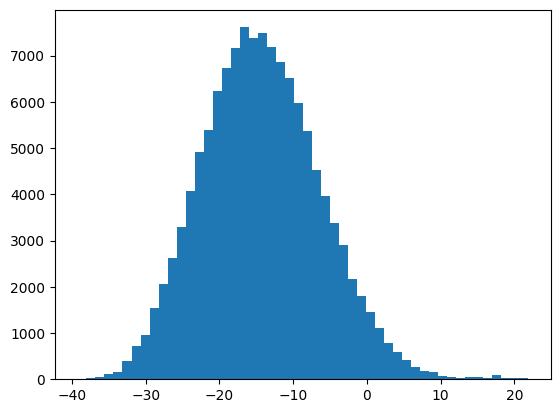

In [20]:
import matplotlib.pyplot as plt
plt.hist(motifmatches_np[:, 168].flatten(), bins=50)
plt.show()

In [26]:
import re
[(i, item) for i, item in enumerate(motifname) if re.match(r"NFY", item, flags=re.IGNORECASE)]

[(37, 'NFYA'), (165, 'NFYB'), (724, 'NFYC')]

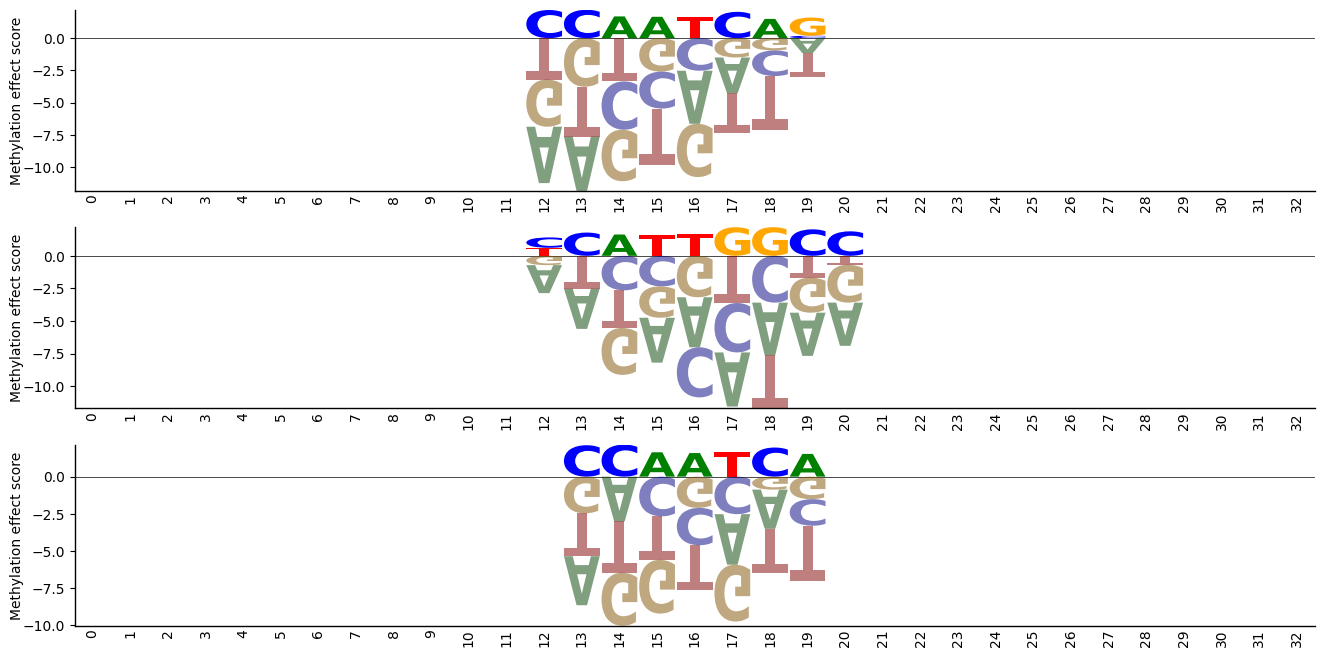

In [49]:
fig, ax = plt.subplots(3,1, figsize=(16,8))
plotfun(motifkernelmat[37], ax=ax[0])
plotfun(motifkernelmat[165], ax=ax[1])
plotfun(motifkernelmat[724], ax=ax[2])

In [50]:
import re
[(i, item) for i, item in enumerate(motifname) if re.match(r"CREB", item, flags=re.IGNORECASE)]

[(8, 'CREB1'),
 (207, 'Creb3l2'),
 (235, 'CREB3'),
 (435, 'CREB3L1'),
 (436, 'Creb5'),
 (581, 'CREB3L4'),
 (582, 'CREB3L4'),
 (935, 'CREB3L3')]

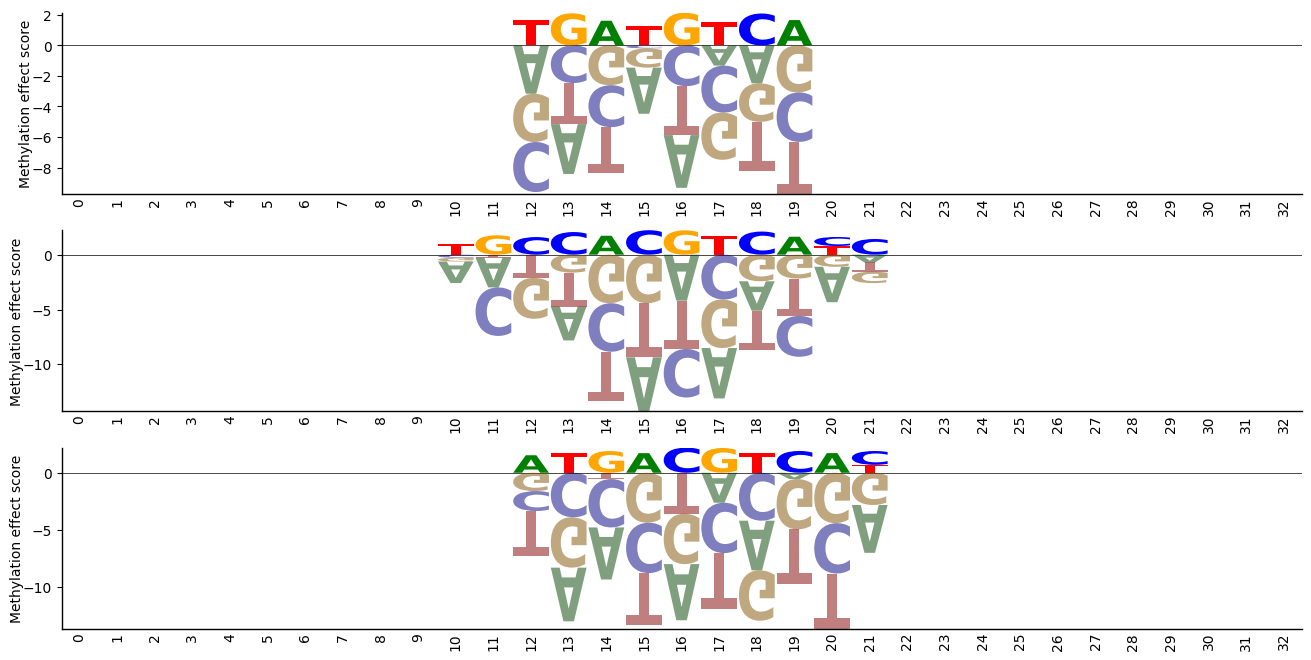

In [55]:
fig, ax = plt.subplots(3,1, figsize=(16,8))
plotfun(motifkernelmat[8], ax=ax[0])
plotfun(motifkernelmat[235], ax=ax[1])
plotfun(motifkernelmat[436], ax=ax[2])

In [56]:
import re
[(i, item) for i, item in enumerate(motifname) if re.match(r"ETS", item, flags=re.IGNORECASE)]

[(67, 'ETS1'), (589, 'ETS2')]

In [64]:
import re
[(i, item) for i, item in enumerate(motifname) if re.match(r"CEBP", item, flags=re.IGNORECASE)]

[(71, 'CEBPA'),
 (130, 'CEBPB'),
 (432, 'CEBPD'),
 (433, 'CEBPE'),
 (434, 'CEBPG'),
 (716, 'CEBPG')]

In [65]:
import re
[(i, item) for i, item in enumerate(motifname) if re.match(r"ONECUT", item, flags=re.IGNORECASE)]

[(276, 'ONECUT1'), (353, 'ONECUT2'), (354, 'ONECUT3')]

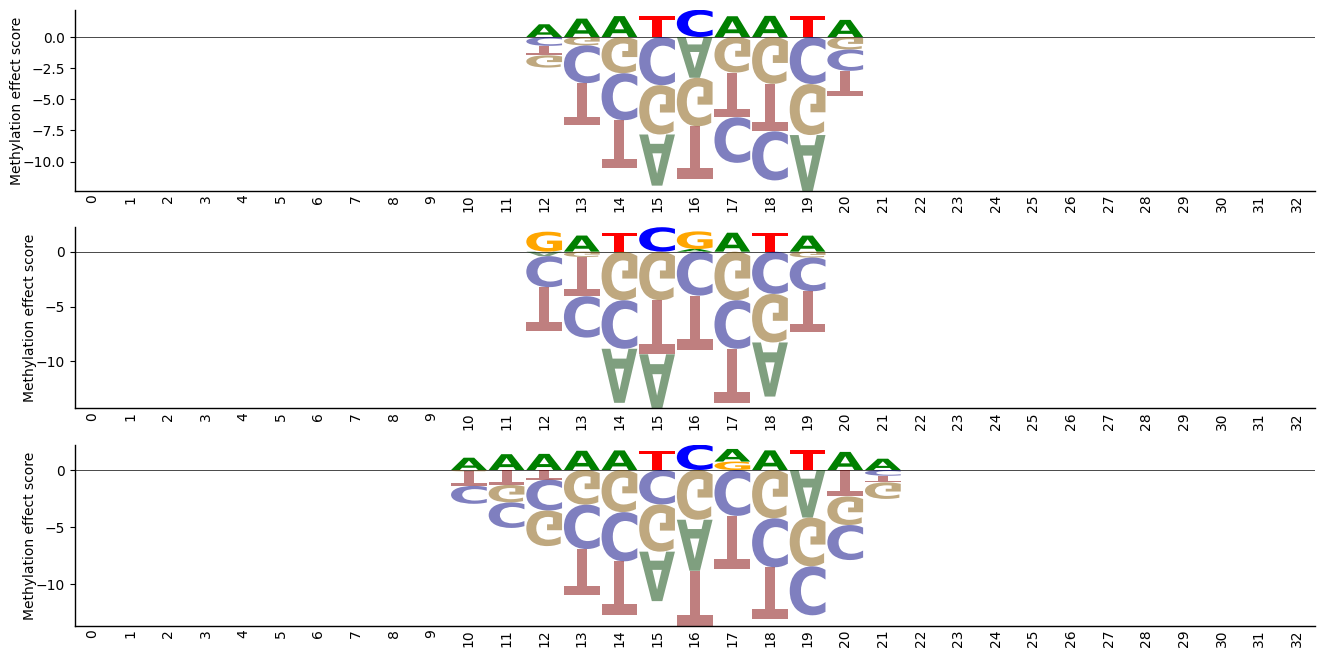

In [66]:
fig, ax = plt.subplots(3,1, figsize=(16,8))
plotfun(motifkernelmat[276], ax=ax[0])
plotfun(motifkernelmat[353], ax=ax[1])
plotfun(motifkernelmat[354], ax=ax[2])

In [67]:
import re
[(i, item) for i, item in enumerate(motifname) if re.match(r"YY", item, flags=re.IGNORECASE)]

[(66, 'Yy1'), (345, 'YY2')]

In [70]:
import re
[(i, item) for i, item in enumerate(motifname) if re.match(r"SP[0-9]+$", item, flags=re.IGNORECASE)]

[(54, 'SP1'),
 (177, 'SP2'),
 (282, 'SP4'),
 (343, 'SP3'),
 (344, 'SP8'),
 (661, 'SP9'),
 (802, 'SP5')]

In [71]:
import re
[(i, item) for i, item in enumerate(motifname) if re.match(r"ZNF143", item, flags=re.IGNORECASE)]

[(60, 'ZNF143')]

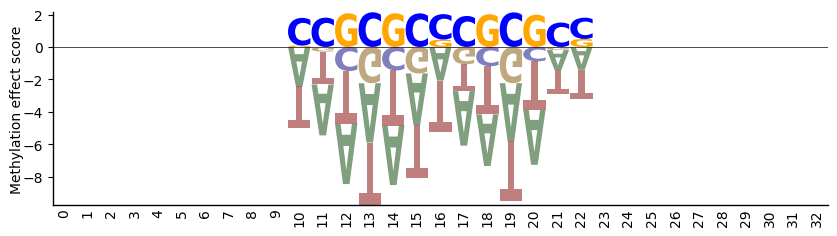

In [72]:
plotfun(motifkernelmat[940])

In [4]:
import re
[(i, item) for i, item in enumerate(motifname) if re.match(r"Mafb", item, flags=re.IGNORECASE)]

[(84, 'Mafb')]

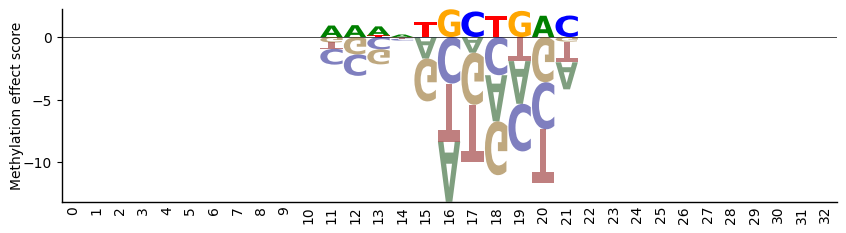

In [6]:
plotfun(motifkernelmat[84])

In [7]:
import re
[(i, item) for i, item in enumerate(motifname) if re.match(r"Gli1", item, flags=re.IGNORECASE)]

[(827, 'Gli1')]

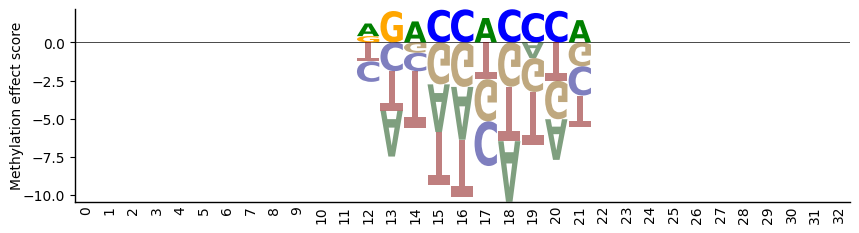

In [8]:
plotfun(motifkernelmat[827])

# Match CG

In [87]:
from tqdm import tqdm

cgkernelmat = torch.zeros(1,4,3).float()
cgkernelmat[0,1,0]=1.0
cgkernelmat[0,2,1]=1.0
CG_matches = []
for i in tqdm(range(all_encoded_data.shape[0])):
    seq = all_encoded_data[i]
    sequence = seq[None,:]
    origseqT = torch.FloatTensor(sequence.copy()).transpose(1,2)

    motifmatch = torch.nn.functional.conv1d(origseqT, cgkernelmat[:,:,:],padding=1).cpu().numpy().squeeze()
    motifmatch[motifmatch==1.0]=0
    CG_matches.append(motifmatch)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 9628.05it/s]


In [88]:
CG_matches = np.array(CG_matches)

In [89]:
CG_matches.shape

(500, 250)

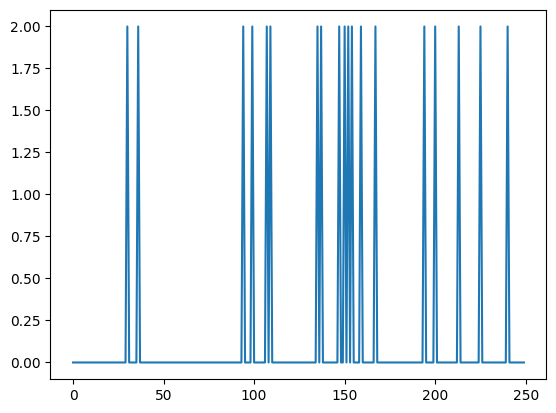

In [90]:
plt.plot(CG_matches[0])

In [91]:
np.save("./intermediate_data/oligo500_cg_screen.npy", CG_matches)